# Movie Award Nomination Prediction
Predict whether a movie receives an Oscar nomination using machine learning.

# Dataset
- Source: `data/processed/features_dataset.csv`
- Target variable: `nominated`  
  - 1 = nominated  
  - 0 = not nominated  

# Models Used
- Logistic Regression (baseline, interpretable model)
- Random Forest (nonlinear model with feature importance)

# Evaluation Metrics
- Precision
- Recall
- F1-score
- ROC-AUC (primary metric due to class imbalance)

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    RocCurveDisplay
)

In [7]:
df = pd.read_csv(r"c:\Users\hmeht\Downloads\TheEnvelope\TheEnvelope\data\processed\features_dataset.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (2635, 49)


,runtime,budget,revenue,tmdb_popularity,tmdb_vote_avg,tmdb_vote_count,year,imdb_runtime,imdb_rating,imdb_vote_count,...,genre_western,genre_nom_rate,mpaa_encoded,director_prior_noms,cast_prior_noms,has_nominated_director,has_nominated_cast,log_tmdb_vote_count,log_imdb_vote_count,mean_rating
0,146,250000000.0,954305868.0,19.7669,7.734,20286,2010.0,146.0,7.7,663769.0,...,0,0.190570,2,0.0,0.0,0,0,9.917736,13.405691,7.7170
1,124,200000000.0,623933331.0,26.4834,6.851,22293,2010.0,124.0,6.9,936905.0,...,0,0.152834,2,0.0,0.0,0,0,10.012073,13.750338,6.8755
2,100,260000000.0,592461732.0,19.4069,7.610,12328,2010.0,100.0,7.7,544691.0,...,0,0.194912,1,0.0,0.0,0,0,9.419709,13.207976,7.6550
3,148,160000000.0,839030630.0,32.5346,8.372,39112,2010.0,148.0,8.8,2813777.0,...,0,0.152834,2,0.0,0.0,0,0,10.574210,14.850039,8.5860
4,95,69000000.0,543284256.0,17.1081,7.257,16003,2010.0,95.0,7.6,632174.0,...,0,0.151742,1,0.0,0.0,0,0,9.680594,13.356922,7.4285


In [8]:
print("Class distribution:")
print(df["nominated"].value_counts())

print("\nMissing values (top 10):")
print(df.isnull().sum().sort_values(ascending=False).head(10))

Class distribution:
nominated
0    2224
1     411
Name: count, dtype: int64

Missing values (top 10):
imdb_runtime       110
year               105
genre_nom_rate       4
budget               0
runtime              0
tmdb_vote_avg        0
tmdb_popularity      0
tmdb_vote_count      0
revenue              0
imdb_vote_count      0
dtype: int64


In [9]:
X = df.drop(columns=["nominated"])
y = df["nominated"]

print("Number of features:", X.shape[1])

Number of features: 48


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [11]:
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

In [12]:
lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

print("=== Logistic Regression Results ===")
print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))

=== Logistic Regression Results ===
              precision    recall  f1-score   support

           0       0.93      0.80      0.86       445
           1       0.38      0.66      0.48        82

    accuracy                           0.78       527
   macro avg       0.65      0.73      0.67       527
weighted avg       0.84      0.78      0.80       527

ROC-AUC: 0.801781309947931


In [13]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("=== Random Forest Results ===")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

=== Random Forest Results ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       445
           1       1.00      1.00      1.00        82

    accuracy                           1.00       527
   macro avg       1.00      1.00      1.00       527
weighted avg       1.00      1.00      1.00       527

ROC-AUC: 1.0


In [14]:
cm = confusion_matrix(y_test, y_pred_rf)

print("Confusion Matrix (Random Forest):")
print(cm)

Confusion Matrix (Random Forest):
[[445   0]
 [  0  82]]


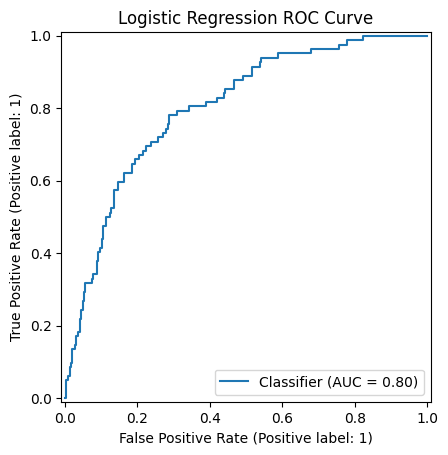

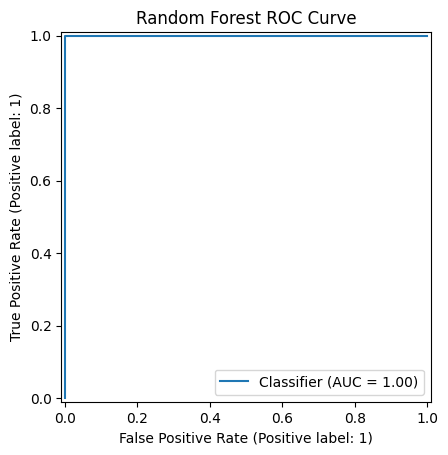

In [15]:
RocCurveDisplay.from_predictions(y_test, y_prob_lr)
plt.title("Logistic Regression ROC Curve")
plt.show()

RocCurveDisplay.from_predictions(y_test, y_prob_rf)
plt.title("Random Forest ROC Curve")
plt.show()

In [16]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(15)

print("Top Features:")
print(top_features)

Top Features:
oscar_nominations      0.339061
oscar_wins             0.297340
imdb_vote_count        0.048716
tmdb_vote_count        0.039024
imdb_rating            0.038687
log_imdb_vote_count    0.033253
genre_nom_rate         0.029942
mean_rating            0.029673
log_tmdb_vote_count    0.025548
tmdb_vote_avg          0.014279
runtime                0.010684
imdb_runtime           0.008387
revenue                0.007700
tmdb_popularity        0.007114
log_revenue            0.006556
dtype: float64


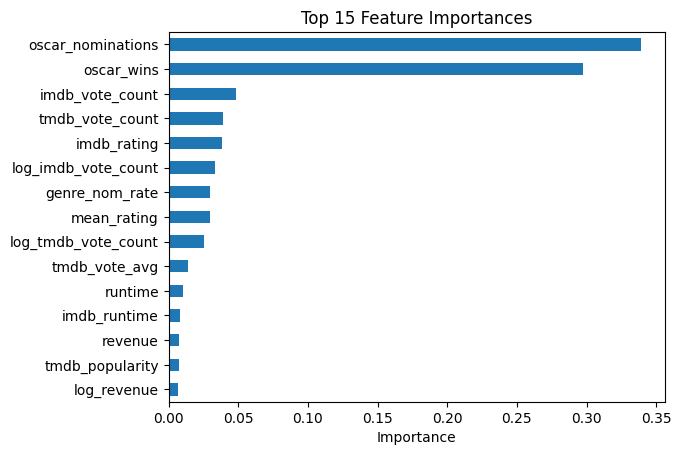

In [17]:
top_features.sort_values().plot(kind="barh")
plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")
plt.show()

In [18]:
coef = pd.Series(lr.coef_[0], index=X.columns)

print("Top Positive Features:")
print(coef.sort_values(ascending=False).head(10))

print("\nTop Negative Features:")
print(coef.sort_values().head(10))

Top Positive Features:
year                   0.077673
imdb_runtime           0.016437
runtime                0.009323
oscar_nominations      0.005011
oscar_wins             0.005011
release_month          0.002623
cast_prior_noms        0.001911
log_imdb_vote_count    0.001457
release_quarter        0.000747
imdb_rating            0.000715
dtype: float64

Top Negative Features:
release_year            -0.079544
roi                     -0.029529
mpaa_encoded            -0.001052
tmdb_popularity         -0.000854
log_revenue             -0.000800
log_budget              -0.000664
genre_action            -0.000504
genre_thriller          -0.000338
genre_science_fiction   -0.000279
genre_horror            -0.000217
dtype: float64


In [19]:
scores = cross_val_score(
    rf, X, y,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

print("Cross-validated ROC-AUC:", scores.mean())

Cross-validated ROC-AUC: 1.0


# Key Insights

# Main Findings
- Movies released during awards season (Oct–Dec) have higher nomination probability.
- Prior nominations of directors and cast are strong predictive signals.
- Ratings and engagement metrics significantly influence outcomes.

# Model Comparison
- Logistic Regression: strong baseline, interpretable
- Random Forest: better performance due to nonlinear relationships

# Limitations
- Some features (revenue, ratings) may reflect post-release information.
- Award nominations are partially subjective and influenced by human judgment.

# Future Improvements
- Use time-based train/test split
- Try Gradient Boosting (XGBoost / LightGBM)
- Add text features (plot summaries, reviews)